# Swiss Solar: tariff changes, PV growth and historical ownership

**Question:** Did municipalities with larger 2023 electricity tariff increases experience larger PV installation increases between 2022 and 2023, and did the relationship differ by historical homeownership?

- **X:** 2023 minus 2022 H4 total tariff (ct/kWh).
- **Y:** annual registered PV commissioning count; compare 2023 − 2022, in counts and per 1,000 fixed 2021 residents.
- **Z:** owner-occupied / all occupied dwellings, census **2000**. Building structure does not replace Z.

## Keep the Data and supporting_inputs folders next to the notebook before running it.

**Results:** [Summary and distributions](#results) · [PV growth](#growth) · [Ownership groups](#ownership) · [Supplementary analyses](#supplementary) · [Findings](#findings)



## 1. Setup
Paths are relative. The short import fallback reuses this project's existing geospatial libraries on the original Python 3.14 machine. Elsewhere, install `requirements.txt` into the selected Jupyter kernel before running.

In [106]:
print (SHARE_DIR)
print (RAW_DIR)
print (RAW_DIR.exists())

/Users/yanjieyumac/Documents/Class coursework/Data Science/Swiss_Solar_Project
/Users/yanjieyumac/Documents/Class coursework/Data Science/Swiss_Solar_Project/Data/raw
True


In [1]:
%pip install geopandas
from pathlib import Path

SHARE_DIR = Path.cwd()
DATA_ROOT = SHARE_DIR / "Data"
RAW_DIR = DATA_ROOT / "raw"
VESE_DIR = DATA_ROOT / "vese_group_share"
SUPPORT_DIR = SHARE_DIR / "supporting_inputs"
RESULT_DIR = SHARE_DIR / "outputs_readable"
PROCESSED_DIR, TABLE_DIR = RESULT_DIR / "processed", RESULT_DIR / "tables"
FIGURE_DIR, REPORT_DIR = RESULT_DIR / "figures", RESULT_DIR / "reports"
for folder in [PROCESSED_DIR, TABLE_DIR, FIGURE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, importlib.util, zipfile, json
local_geospatial = SHARE_DIR.parent / ".python_dependencies"
if importlib.util.find_spec("geopandas") is None:
    if sys.version_info[:2] == (3, 14) and local_geospatial.is_dir():
        sys.path.insert(0, str(local_geospatial))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from IPython.display import display, Markdown
%matplotlib inline

In [3]:
pd.set_option("display.max_columns", 14)
pd.set_option("display.max_rows", 16)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams.update({"figure.figsize": (8, 4.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2. Data preparation
### Municipality IDs
Use 2026 IDs and the original merger-chain rules. Census 2000 uses the full official correspondence; ambiguous historical splits invalidate ownership for affected destinations.

In [4]:
mutations = pd.read_csv(SUPPORT_DIR / "bfs_commune_mutations.csv")
correspondence = pd.read_csv(SUPPORT_DIR / "bfs_correspondence_2000_2026.csv")
communes = pd.read_csv(SUPPORT_DIR / "bfs_levels_2026.csv")
print("Source table rows:", len(mutations), len(correspondence), len(communes))

Source table rows: 1445 2927 2110


In [5]:
communes = communes[["BfsCode", "Name", "CantonId", "Canton"]].rename(
    columns={"BfsCode": "bfs", "Name": "commune", "CantonId": "canton_id", "Canton": "canton"})
assert communes.bfs.is_unique
valid_ids = set(communes.bfs)
print("2026 municipalities:", len(communes))

2026 municipalities: 2110


In [6]:
links = mutations.loc[mutations.InitialCode != mutations.TerminalCode,
                      ["InitialCode", "TerminalCode"]].drop_duplicates()
assert links.InitialCode.is_unique, "One-to-many changes require separate treatment."
next_id = dict(zip(links.InitialCode, links.TerminalCode))
print("Non-self links:", len(links))

Non-self links: 616


In [7]:
def to_2026(value):
    if pd.isna(value):
        return np.nan
    value = int(value)
    visited = set()
    while value in next_id:
        assert value not in visited, "Cycle in commune crosswalk."
        visited.add(value)
        value = int(next_id[value])
    return value

In [8]:
number_of_targets = correspondence.groupby("InitialCode").TerminalCode.nunique()
split_sources = number_of_targets[number_of_targets > 1].index
uncertain_geography = set(correspondence.loc[
    correspondence.InitialCode.isin(split_sources), "TerminalCode"])
z_links = correspondence.loc[~correspondence.InitialCode.isin(split_sources),
                             ["InitialCode", "TerminalCode"]].drop_duplicates()
assert z_links.InitialCode.is_unique
census_map = dict(zip(z_links.InitialCode, z_links.TerminalCode))
communes["geography_reliable"] = ~communes.bfs.isin(uncertain_geography)
print("Ambiguous census source IDs:", len(split_sources), "; affected destinations:", len(uncertain_geography))

Ambiguous census source IDs: 23 ; affected destinations: 13


In [9]:
display(communes.loc[~communes.geography_reliable, ["bfs", "commune", "canton"]])

,bfs,commune,canton
1036,5249,Castel San Pietro,Ticino
1350,5269,Breggia,Ticino
1770,24,Buch am Irchel,Zürich
1771,223,Neftenbach,Zürich
1885,1081,Beromünster,Luzern
1886,1099,Schenkon,Luzern
2047,5138,Cugnasco-Gerra,Ticino
2048,5112,Lavertezzo,Ticino
2049,5399,Verzasca,Ticino
2092,62,Kloten,Zürich


### X: household tariffs
Keep H4 2022/2023 totals. Remove identical duplicates, exclude conflicting totals, then average within municipality/operator/year and equally across operators. Matched-operator X is a sensitivity check only.

In [10]:
tariffs = pd.read_csv(RAW_DIR / "elcom_tariffs_H2_H4_H7.csv")
print("Source shape:", tariffs.shape)
display(tariffs.isna().sum().to_frame("missing"))

Source shape: (126086, 10)


,missing
period,0
municipality,0
operator,0
category,0
total,0
energy,0
grid,0
charge,0
aidfee,0
fixcosts,0


In [11]:
h4 = tariffs.loc[(tariffs.category == "H4") & tariffs.period.isin([2022, 2023])].copy()
h4["bfs"] = h4.municipality.map(to_2026)
tariff_keys = ["municipality", "operator", "period"]
conflicts = h4.groupby(tariff_keys).total.nunique()
conflicts = conflicts[conflicts > 1].reset_index(name="distinct_totals")
conflicting_ids = set(conflicts.municipality.map(to_2026))
display(conflicts)

,municipality,operator,period,distinct_totals
0,6459,691,2023,2


In [12]:
# Remove repeated observations of the same total before averaging.
h4_unique = h4.drop_duplicates(tariff_keys + ["total"])
h4_valid = h4_unique[h4_unique.bfs.isin(valid_ids) & ~h4_unique.bfs.isin(conflicting_ids)].copy()
operator_tariffs = h4_valid.groupby(["bfs", "operator", "period"], as_index=False).agg(
    total=("total", "mean"), predecessor_count=("municipality", "nunique"))
print("Valid operator-year rows:", len(operator_tariffs))

Valid operator-year rows: 4601


In [13]:
annual_tariffs = operator_tariffs.groupby(["bfs", "period"], as_index=False).agg(
    tariff=("total", "mean"), n_operators=("operator", "nunique"),
    min_tariff=("total", "min"), max_tariff=("total", "max"))

In [14]:
wide_x = annual_tariffs.pivot(index="bfs", columns="period")
wide_x.columns = [f"{name}_{year}" for name, year in wide_x.columns]
clean_x = communes.merge(wide_x.reset_index(), on="bfs", how="left", validate="1:1")
clean_x["X"] = clean_x.tariff_2023 - clean_x.tariff_2022
clean_x["tariff_conflict"] = clean_x.bfs.isin(conflicting_ids)

In [15]:
operator_pairs = operator_tariffs.pivot(index=["bfs", "operator"], columns="period", values="total")
operator_pairs["pair_change"] = operator_pairs[2023] - operator_pairs[2022]
same_operator_x = operator_pairs.groupby("bfs").agg(
    X_same_operators=("pair_change", "mean"), n_paired_operators=("pair_change", "count"))
clean_x = clean_x.merge(same_operator_x, on="bfs", how="left", validate="1:1")
clean_x["stable_operator_set"] = ((clean_x.n_paired_operators == clean_x.n_operators_2022)
                                  & (clean_x.n_paired_operators == clean_x.n_operators_2023))

In [16]:
clean_x.to_csv(PROCESSED_DIR / "clean_X.csv", index=False)
print("Valid X:", clean_x.X.notna().sum(), "| Multiple operators in 2023:", (clean_x.n_operators_2023 > 1).sum())

Valid X: 2097 | Multiple operators in 2023: 135


In [17]:
display(clean_x[["bfs", "commune", "tariff_2022", "tariff_2023", "X"]].head())

,bfs,commune,tariff_2022,tariff_2023,X
0,6158,Vionnaz,20.8940,31.9370,11.0430
1,3023,Speicher,20.2830,26.7230,6.4400
2,6011,Zwischbergen,8.1930,8.4930,0.3000
3,2228,Villars-sur-Glâne,21.1570,25.3520,4.1950
4,2230,Villarsel-sur-Marly,21.1570,25.3520,4.1950


### Y: registered PV installations
Use commissioning dates for all PV categories. Assign coordinates first, then unambiguous postal matches, retaining the reference's boundary and location rules. These counts are not restricted to residential rooftops.

In [18]:
print("Reading plant records and catalogues...", flush=True)
with zipfile.ZipFile(RAW_DIR / "bfe_plants.csv.zip") as archive:
    plants = pd.read_csv(archive.open("ElectricityProductionPlant.csv"))
    subcategories = pd.read_csv(archive.open("SubCategoryCatalogue.csv"))
    mounting = pd.read_csv(archive.open("PlantCategoryCatalogue.csv"))
    snapshot_timestamp = archive.getinfo("ElectricityProductionPlant.csv").date_time
print("Plant records:", len(plants), "; snapshot timestamp:", snapshot_timestamp)

Reading plant records and catalogues...
Plant records: 339499 ; snapshot timestamp: (2026, 9, 14, 13, 13, 24)


In [19]:
display(subcategories[["Catalogue_id", "en"]])
display(mounting[mounting.Catalogue_id.isin(["plantcat_8", "plantcat_9", "plantcat_10"])][["Catalogue_id", "en"]])
print("Duplicate plant IDs:", plants.xtf_id.duplicated().sum())
assert plants.xtf_id.is_unique

,Catalogue_id,en
0,subcat_1,Hydroelectric power
1,subcat_2,Photovoltaic
2,subcat_3,Wind energy
3,subcat_4,Biomass
4,subcat_5,Geothermal energy
5,subcat_6,Nuclear energy
6,subcat_7,Crude oil
7,subcat_8,Natural gas
8,subcat_9,Coal
9,subcat_10,Waste


,Catalogue_id,en
7,plantcat_8,Attached
8,plantcat_9,Integrated
9,plantcat_10,Freestanding


Duplicate plant IDs: 0


In [20]:
solar = plants.loc[plants.SubCategory == "subcat_2"].copy()
solar["date"] = pd.to_datetime(solar.BeginningOfOperation, errors="coerce")
solar["year"] = solar.date.dt.year
solar["known_rooftop"] = solar.PlantCategory.isin(["plantcat_8", "plantcat_9"])
solar["unknown_mounting"] = solar.PlantCategory.isna()

In [21]:
display(solar.PlantCategory.fillna("Unknown").value_counts().rename("plants").to_frame())
display(solar.groupby("year").size().rename("solar_records").to_frame().tail(16))
print("Missing/invalid dates:", solar.date.isna().sum(), "| Snapshot:", snapshot_timestamp)
print("Missing coordinates:", solar[["_x", "_y"]].isna().any(axis=1).sum())

,plants
PlantCategory,
plantcat_8,283574
plantcat_9,42205
Unknown,10271
plantcat_10,1405


,solar_records
year,
2011,4572
2012,7006
2013,7398
2014,7309
2015,13252
2016,10630
2017,13208
2018,13139
2019,14548


Missing/invalid dates: 0 | Snapshot: (2026, 9, 14, 13, 13, 24)
Missing coordinates: 2387


In [22]:
print("Reading boundary polygons...", flush=True)
boundaries_raw = gpd.read_file(RAW_DIR / "swiss_boundaries_2020.geojson")
print("CRS:", boundaries_raw.crs)

Reading boundary polygons...
CRS: EPSG:4326


In [23]:
print("Harmonizing and dissolving municipal boundaries...", flush=True)
boundaries = boundaries_raw.loc[(boundaries_raw.OBJEKTART == "Gemeindegebiet")
                               & (boundaries_raw.ICC == "CH"), ["BFS_NUMMER", "geometry"]].copy()
boundaries["bfs"] = boundaries.BFS_NUMMER.map(to_2026)
boundaries = boundaries[boundaries.bfs.isin(valid_ids)][["bfs", "geometry"]].dissolve(by="bfs").reset_index()
assert boundaries.crs.to_epsg() == 4326 and boundaries.is_valid.all()
print("Municipal polygons:", len(boundaries))

Harmonizing and dissolving municipal boundaries...
Municipal polygons: 2110


In [24]:
print("Converting plant coordinates...", flush=True)
has_xy = solar[["_x", "_y"]].notna().all(axis=1)
points = gpd.GeoDataFrame(solar.loc[has_xy, ["xtf_id"]],
                         geometry=gpd.points_from_xy(solar.loc[has_xy, "_x"], solar.loc[has_xy, "_y"]),
                         crs="EPSG:2056").to_crs(boundaries.crs)
print("Coordinate points:", len(points), "；CRS:", points.crs)

Converting plant coordinates...
Coordinate points: 335068 ；CRS: EPSG:4326


In [25]:
print("Matching coordinates to municipalities...", flush=True)
spatial = gpd.sjoin(points, boundaries, how="left", predicate="intersects")
unique_spatial = spatial.groupby("xtf_id").bfs.nunique()
spatial = spatial[spatial.xtf_id.isin(unique_spatial[unique_spatial == 1].index)].drop_duplicates("xtf_id")
solar["bfs"] = solar.xtf_id.map(spatial.set_index("xtf_id").bfs)
solar["assignment"] = np.where(solar.bfs.notna(), "coordinates", "unresolved")
display(solar.assignment.value_counts().to_frame("records"))

Matching coordinates to municipalities...


,records
assignment,
coordinates,335066
unresolved,2389


In [26]:
with zipfile.ZipFile(SUPPORT_DIR / "ortschaftenverzeichnis_plz.csv.zip") as archive:
    member = [name for name in archive.namelist() if name.endswith(".csv")][0]
    postcodes = pd.read_csv(archive.open(member), sep=";")

In [27]:
postcodes["bfs"] = postcodes["BFS-Nr"].map(to_2026)
postcodes = postcodes[postcodes.bfs.isin(valid_ids)].copy()
postcodes["postcode"] = postcodes.PLZ4.astype(str).str.zfill(4)
postcodes["locality"] = postcodes.Ortschaftsname.astype(str).str.strip().str.casefold()
postcodes["canton_code"] = postcodes["Kantonskürzel"]
solar["postcode"] = solar.PostCode.astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(4)
solar["locality"] = solar.Municipality.astype(str).str.strip().str.casefold()
solar["canton_code"] = solar.Canton

In [28]:
print("Applying unambiguous postal fallbacks...", flush=True)
for keys, method in [(["postcode", "locality", "canton_code"], "postcode_locality"),
                     (["postcode", "canton_code"], "postcode_unique")]:
    lookup = postcodes.groupby(keys).bfs.agg(["nunique", "first"]).reset_index()
    lookup = lookup.loc[lookup["nunique"] == 1]
    missing = solar.loc[solar.bfs.isna(), ["xtf_id"] + keys]
    fallback = missing.merge(lookup[keys + ["first"]], on=keys, how="left", validate="m:1")
    mapping = fallback.set_index("xtf_id")["first"]
    suggested = solar.xtf_id.map(mapping)
    matched = solar.bfs.isna() & suggested.notna()
    solar.loc[matched, "bfs"] = suggested[matched]
    solar.loc[matched, "assignment"] = method
display(solar.assignment.value_counts().to_frame("records"))

Applying unambiguous postal fallbacks...


,records
assignment,
coordinates,335066
postcode_locality,1527
unresolved,859
postcode_unique,3


In [29]:
solar["bfs"] = solar.bfs.astype("Int64")
solar_period = solar[solar.year.between(2015, 2025)].copy()
geocoding_audit = solar_period.groupby(["year", "assignment"]).size().unstack(fill_value=0)
geocoding_audit["total"] = geocoding_audit.sum(axis=1)
geocoding_audit["assigned_share"] = 1 - geocoding_audit.get("unresolved", 0) / geocoding_audit.total
geocoding_audit.to_csv(TABLE_DIR / "geocoding_audit.csv")
display(geocoding_audit)
unresolved = solar_period[solar_period.bfs.isna()]

assignment,coordinates,postcode_locality,postcode_unique,unresolved,total,assigned_share
year,,,,,,
2015,13147,74,0,31,13252,0.9977
2016,10597,24,0,9,10630,0.9992
2017,13185,12,0,11,13208,0.9992
2018,13119,11,0,9,13139,0.9993
2019,14523,19,0,6,14548,0.9996
2020,19463,24,0,9,19496,0.9995
2021,23252,46,0,31,23329,0.9987
2022,33542,136,0,85,33763,0.9975
2023,61257,336,0,172,61765,0.9972


In [30]:
# Canton abbreviations are stable official codes, aligned with BFS canton numbers.
canton_codes = dict(enumerate(["ZH", "BE", "LU", "UR", "SZ", "OW", "NW", "GL", "ZG", "FR",
                              "SO", "BS", "BL", "SH", "AR", "AI", "SG", "GR", "AG", "TG",
                              "TI", "VD", "VS", "NE", "GE", "JU"], start=1))
communes["canton_code"] = communes.canton_id.map(canton_codes)
# Include Moutier's pre-2026 canton in uncertain assignments, if relevant.
# Postal canton labels can disagree with geographic coordinates near borders.
solar_period["assigned_canton"] = solar_period.bfs.map(communes.set_index("bfs").canton_code)
label_conflict = (solar_period.assignment.eq("coordinates")
                  & solar_period.assigned_canton.ne(solar_period.canton_code)
                  & ~solar_period.bfs.eq(6831))  # Moutier moved from BE to JU in 2026.
label_conflict = label_conflict.fillna(False)
location_label_audit = solar_period.loc[label_conflict].groupby(
    ["canton_code", "assigned_canton"]).size().rename("records").reset_index()
location_label_audit.to_csv(TABLE_DIR / "location_label_disagreements.csv", index=False)
print("Coordinate assignments disagreeing with canton label, excluding Moutier transfer:", int(label_conflict.sum()))
print("Coordinates retained as specified; postal labels are not authoritative commune locations.")

Coordinate assignments disagreeing with canton label, excluding Moutier transfer: 498
Coordinates retained as specified; postal labels are not authoritative commune locations.


In [31]:
print("Marking municipality-years potentially affected by unresolved records...", flush=True)
postal_candidates = postcodes[["postcode", "canton_code", "bfs"]].drop_duplicates()
uncertain_cells = []
for row in unresolved.itertuples():
    candidates = postal_candidates.loc[(postal_candidates.postcode == row.postcode)
                                       & (postal_candidates.canton_code == row.canton_code), "bfs"]
    if candidates.empty:
        candidates = communes.loc[communes.canton_code == row.canton_code, "bfs"]
        if row.canton_code == "BE":
            candidates = pd.concat([candidates, pd.Series([6831])])
    if candidates.empty:
        candidates = communes.bfs
    uncertain_cells.extend((int(bfs), int(row.year)) for bfs in candidates)
uncertain_cells = set(uncertain_cells)
print("Potentially affected municipality-year keys:", len(uncertain_cells))

Marking municipality-years potentially affected by unresolved records...
Potentially affected municipality-year keys: 1193


Unresolved plants make potentially affected municipality-years unknown, including partial positive counts. Empty cells are usable register zeros only with a polygon and no unresolved-location risk.

In [32]:
assigned = solar_period[solar_period.bfs.notna()].copy()
assigned["coordinate_assigned"] = assigned.assignment.eq("coordinates")
counts = assigned.groupby(["bfs", "year"]).agg(
    Y_registered=("xtf_id", "size"), Y_rooftop_registered=("known_rooftop", "sum"),
    Y_coordinate_only=("coordinate_assigned", "sum"), unknown_mounting_count=("unknown_mounting", "sum"))
counts = counts.reset_index()
print("Assigned 2015–2025 records:", counts.Y_registered.sum())

Assigned 2015–2025 records: 297367


In [33]:
grid = pd.MultiIndex.from_product([sorted(valid_ids), range(2015, 2026)], names=["bfs", "year"]).to_frame(index=False)
clean_y = grid.merge(counts, on=["bfs", "year"], how="left", validate="1:1")
count_columns = ["Y_registered", "Y_rooftop_registered", "Y_coordinate_only", "unknown_mounting_count"]
clean_y[count_columns] = clean_y[count_columns].fillna(0).astype(int)
clean_y["unresolved_location_risk"] = [(int(b), int(y)) in uncertain_cells for b, y in zip(clean_y.bfs, clean_y.year)]
clean_y["has_polygon"] = clean_y.bfs.isin(boundaries.bfs)
clean_y["Y"] = clean_y.Y_registered.where(~clean_y.unresolved_location_risk & clean_y.has_polygon)
clean_y["register_zero"] = clean_y.Y_registered.eq(0)
print("Missing main Y cells:", clean_y.Y.isna().sum())

Missing main Y cells: 1193


In [34]:
clean_y.to_csv(PROCESSED_DIR / "clean_Y.csv", index=False)
assert clean_y.Y_registered.sum() == len(assigned)
assert not clean_y.duplicated(["bfs", "year"]).any()
print("Proposed rows:", len(clean_y), "| Y missing due to location/coverage risk:", clean_y.Y.isna().sum())
print("Register-zero cells:", clean_y.register_zero.sum(), "| Usable register-zero cells:", clean_y.Y.eq(0).sum())

Proposed rows: 23210 | Y missing due to location/coverage risk: 1193
Register-zero cells: 1983 | Usable register-zero cells: 1956


### Z: historical ownership
Sum the three owner categories and all eight occupied-dwelling categories across room bands and predecessor municipalities, then divide. Vacant dwellings are outside this source. Original source labels are retained for exact matching.

In [35]:
dwellings = pd.read_csv(RAW_DIR / "bfs_dwellings_by_occupant_2000_all.csv")
print("Source shape:", dwellings.shape)

Source shape: (28970, 10)


In [36]:
occupant_columns = dwellings.columns[2:].tolist()
owner_columns = ["Stockwerk-/Wohnungseigentümer/in", "Alleineigentümer/in des Hauses", "Miteigentümer/in des Hauses"]
display(pd.DataFrame({"category": occupant_columns, "in_owner_numerator": [c in owner_columns for c in occupant_columns]}))
display(dwellings["Anzahl Zimmer"].value_counts().to_frame("rows"))
assert not dwellings.duplicated(["Gemeinde", "Anzahl Zimmer"]).any()
assert dwellings[occupant_columns].notna().all().all()
assert (dwellings[occupant_columns] >= 0).all().all()

,category,in_owner_numerator
0,Mieter/in,False
1,Genossenschafter/in,False
2,Stockwerk-/Wohnungseigentümer/in,True
3,Alleineigentümer/in des Hauses,True
4,Miteigentümer/in des Hauses,True
5,Inhaber/in einer Dienstwohnung,False
6,Inhaber/in einer Freiwohnung,False
7,Pächter/in,False


,rows
Anzahl Zimmer,
1 Zimmer,2897
2 Zimmer,2897
3 Zimmer,2897
4 Zimmer,2897
5 Zimmer,2897
6 Zimmer,2897
7 Zimmer,2897
8 Zimmer,2897
9 Zimmer,2897


In [37]:
dwellings["old_bfs"] = pd.to_numeric(dwellings.Gemeinde.str.extract(r"^(\d+)")[0], errors="coerce")
census = dwellings[dwellings.old_bfs.notna()].copy()
assert set(census.old_bfs).issubset(set(correspondence.InitialCode))
assert np.array_equal(census[occupant_columns].sum().values,
                      dwellings.loc[dwellings.Gemeinde == "Schweiz", occupant_columns].sum().values)
print("Municipal census rows:", len(census))
print("National category totals verified.")

Municipal census rows: 28960
National category totals verified.


In [38]:
census["owner_dwellings"] = census[owner_columns].sum(axis=1)
census["occupied_dwellings"] = census[occupant_columns].sum(axis=1)
census["bfs"] = census.old_bfs.map(census_map)
census_usable = census[census.bfs.isin(valid_ids) & ~census.bfs.isin(uncertain_geography)].copy()
z_counts = census_usable.groupby("bfs", as_index=False)[["owner_dwellings", "occupied_dwellings"]].sum()

In [39]:
clean_z = communes.merge(z_counts, on="bfs", how="left", validate="1:1")
clean_z["Z"] = clean_z.owner_dwellings / clean_z.occupied_dwellings.replace(0, np.nan)
assert clean_z.Z.dropna().between(0, 1).all()

In [40]:
clean_z.to_csv(PROCESSED_DIR / "clean_Z.csv", index=False)
print("National dwelling-weighted ownership share:", round(census.owner_dwellings.sum()/census.occupied_dwellings.sum(), 4))
print("Unweighted modern-commune median before sample selection:", round(clean_z.Z.median(), 4))

National dwelling-weighted ownership share: 0.3459
Unweighted modern-commune median before sample selection: 0.5638


### Population and other characteristics
Use fixed 2021 population for normalization. Income and building structure are descriptive checks only; they do not replace Z or restrict the core sample.

In [41]:
population_raw = pd.read_csv(RAW_DIR / "bfs_population.csv", encoding="latin1")
print("Years:", sorted(population_raw.Jahr.unique()))

Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [42]:
location_column = "Kanton (-) / Bezirk (>>) / Gemeinde (......)"
population_raw["old_bfs"] = pd.to_numeric(population_raw[location_column].str.extract(r"^\.{6}(\d+)")[0], errors="coerce")
population_raw["bfs"] = population_raw.old_bfs.map(to_2026)
population = population_raw[population_raw.bfs.isin(valid_ids)].copy()
assert not population.duplicated(["old_bfs", "Jahr"]).any()
print("Retained municipality-year source rows:", len(population))

Retained municipality-year source rows: 33840


In [43]:
population = population.groupby(["bfs", "Jahr"], as_index=False)["Alter - Total"].sum().rename(
    columns={"Jahr": "year", "Alter - Total": "population"})
pop2021 = population.loc[population.year == 2021, ["bfs", "population"]].rename(columns={"population": "population_2021"})
display(population.groupby("year").agg(communes=("bfs", "nunique"), population=("population", "sum")))

,communes,population
year,,
2010,2110,7870134
2011,2110,7954662
2012,2110,8039060
2013,2110,8139631
2014,2110,8237666
2015,2110,8327126
2016,2110,8419550
2017,2110,8484130
2018,2110,8544527


In [44]:
income_raw = pd.read_csv(RAW_DIR / "estv_municipal_income_2021.csv")

In [45]:
income = income_raw[income_raw.bfs.between(1, 8999)].copy()
assert income.bfs.is_unique
income["bfs"] = income.bfs.map(to_2026)
income = income[income.bfs.isin(valid_ids)].groupby("bfs", as_index=False)[["inc_total", "taxpayers_total"]].sum(min_count=1)
income["income_2021"] = income.inc_total / income.taxpayers_total.replace(0, np.nan)

In [46]:
buildings_raw = pd.read_csv(RAW_DIR / "bfs_gws_buildings_2015_2024.csv", dtype={"GEMEINDENAME": str, "GKATS": str})

In [47]:
buildings = buildings_raw[(buildings_raw.TIME_PERIOD == 2021) & (buildings_raw.GBAUPS == "_T")].copy()
buildings["bfs"] = pd.to_numeric(buildings.GEMEINDENAME, errors="coerce").map(to_2026)
buildings = buildings[buildings.bfs.isin(valid_ids)]
assert not buildings.duplicated(["GEMEINDENAME", "GKATS"]).any()
buildings = buildings.groupby(["bfs", "GKATS"]).OBS_VALUE.sum(min_count=1).unstack()
buildings["single_family_share_2021"] = buildings["1021"] / buildings["_T"].replace(0, np.nan)
assert buildings.single_family_share_2021.dropna().between(0, 1).all()

In [48]:
characteristics = pop2021.merge(income[["bfs", "income_2021"]], on="bfs", how="left", validate="1:1")
characteristics = characteristics.merge(buildings[["single_family_share_2021"]], on="bfs", how="left", validate="1:1")
display(characteristics.isna().mean().to_frame("missing_share"))

,missing_share
bfs,0.0000
population_2021,0.0000
income_2021,0.0000
single_family_share_2021,0.0000


## 3. Analytical samples
The core sample requires valid X, historical Z/geography, usable 2022/2023 Y, and positive finite 2021 population. Only the supplementary balanced sample requires all eleven Y years, 2015–2025.

In [49]:
commune_data = communes.merge(clean_x[["bfs", "X", "X_same_operators", "stable_operator_set", "tariff_conflict",
                                      "n_operators_2022", "n_operators_2023"]], on="bfs", validate="1:1")
commune_data = commune_data.merge(clean_z[["bfs", "Z", "occupied_dwellings"]], on="bfs", validate="1:1")
commune_data = commune_data.merge(characteristics, on="bfs", how="left", validate="1:1")
y_complete = clean_y.groupby("bfs").Y.count().eq(11).rename("all_years_Y_usable")
commune_data = commune_data.merge(y_complete, on="bfs", validate="1:1")
display(commune_data[["X", "Z", "population_2021"]].notna().mean().to_frame("available_share"))
print("Municipal universe:", len(commune_data))

,available_share
X,0.9938
Z,0.9938
population_2021,1.0000


Municipal universe: 2110


In [50]:
y_all = clean_y.pivot(index="bfs", columns="year", values="Y")
two_year_ok = y_all[[2022, 2023]].notna().all(axis=1).rename("two_year_Y_usable")
commune_data = commune_data.merge(two_year_ok, on="bfs", validate="1:1")
commune_data["population_valid"] = np.isfinite(commune_data.population_2021) & commune_data.population_2021.gt(0)
y_availability = y_all.notna().sum().rename("usable_communes").to_frame()
display(y_availability)
print("Both Y years usable:", int(two_year_ok.sum()))

,usable_communes
year,
2015,2042
2016,2088
2017,2081
2018,2083
2019,2095
2020,2086
2021,2044
2022,1928
2023,1841


Both Y years usable: 1726


In [51]:
eligibility = pd.DataFrame(index=commune_data.index)
eligibility["Valid X"] = commune_data.X.notna()
eligibility["Valid historical Z/geography"] = commune_data.Z.notna() & commune_data.geography_reliable
eligibility["Usable Y in 2022 and 2023"] = commune_data.two_year_Y_usable
eligibility["Positive finite 2021 population"] = commune_data.population_valid
keep = pd.Series(True, index=commune_data.index)
sample_flow = []

In [52]:
for condition in eligibility:
    before = int(keep.sum())
    keep = keep & eligibility[condition]
    sample_flow.append({"condition": condition, "before": before,
                        "retained": int(keep.sum()), "excluded": before - int(keep.sum())})
commune_data["in_core"] = keep
commune_data["in_analysis"] = keep
commune_data["in_balanced"] = keep & commune_data.all_years_Y_usable
sample_flow = pd.DataFrame(sample_flow)
sample_flow.to_csv(TABLE_DIR / "sample_flow.csv", index=False)
display(sample_flow)

,condition,before,retained,excluded
0,Valid X,2110,2097,13
1,Valid historical Z/geography,2097,2084,13
2,Usable Y in 2022 and 2023,2084,1704,380
3,Positive finite 2021 population,1704,1704,0


In [53]:
missing_years = {}
for bfs, row in y_all.iterrows():
    unavailable = row.index[row.isna()].astype(int).astype(str)
    missing_years[bfs] = ",".join(unavailable)
commune_data["missing_Y_years"] = commune_data.bfs.map(missing_years)
commune_data["newly_included"] = commune_data.in_core & ~commune_data.in_balanced
commune_data["original_exclusion_reason"] = np.where(commune_data.newly_included,
    "Excluded by 11-year Y completeness; now both 2022 and 2023 are usable", "")

In [54]:
newly_included = commune_data[commune_data.newly_included].copy()
newly_included.to_csv(TABLE_DIR / "newly_included_communes.csv", index=False)
print("Added relative to the fixed balanced sample:", len(newly_included))
display(newly_included[["bfs", "commune", "canton", "missing_Y_years"]].head(8))

Added relative to the fixed balanced sample: 246


,bfs,commune,canton,missing_Y_years
1,3023,Speicher,Appenzell Ausserrhoden,2024
8,121,Wetzikon (ZH),Zürich,2024
15,1323,Wollerau,Schwyz,2024
24,182,Wildberg,Zürich,2024
28,230,Winterthur,Zürich,2024
33,4082,Wohlen (AG),Aargau,"2021,2025"
40,1218,Spiringen,Uri,2025
46,6159,Vouvry,Valais / Wallis,2020


In [55]:
commune_data["exclusion_reason"] = ""
for condition, text in [(commune_data.X.isna(), "Missing/conflicting X; "),
    (commune_data.Z.isna() | ~commune_data.geography_reliable, "Unusable Z/geography; "),
    (~commune_data.two_year_Y_usable, "Unusable Y in 2022/2023; "),
    (~commune_data.population_valid, "Invalid 2021 population; ")]:
    commune_data.loc[condition, "exclusion_reason"] += text
commune_data.to_csv(TABLE_DIR / "commune_sample_status.csv", index=False)
display(commune_data.exclusion_reason.value_counts().to_frame("communes"))

,communes
exclusion_reason,
,1704
Unusable Y in 2022/2023;,380
Missing/conflicting X;,12
Unusable Z/geography;,10
Unusable Z/geography; Unusable Y in 2022/2023;,3
Missing/conflicting X; Unusable Y in 2022/2023;,1


In [56]:
analytical_panel = clean_y.merge(commune_data, on="bfs", how="left", validate="m:1")
analytical_panel = analytical_panel.merge(population, on=["bfs", "year"], how="left", validate="1:1")
analytical_panel["installations_per_1000_2021"] = 1000 * analytical_panel.Y / analytical_panel.population_2021
commune_sample = commune_data[commune_data.in_core].copy()
balanced_communes = commune_data[commune_data.in_balanced].copy()
panel = analytical_panel[analytical_panel.in_core & analytical_panel.year.isin([2022, 2023])].copy()
trend_panel = analytical_panel[analytical_panel.in_balanced].copy()
print("Core municipalities:", len(commune_sample), "; two-year rows:", len(panel))
print("Fixed balanced municipalities:", len(balanced_communes), "; eleven-year rows:", len(trend_panel))

Core municipalities: 1704 ; two-year rows: 3408
Fixed balanced municipalities: 1458 ; eleven-year rows: 16038


In [57]:
ownership_median = commune_sample.Z.median()
shock_cuts = commune_sample.X.quantile([1/3, 2/3]).to_numpy()
commune_sample["ownership_group"] = np.where(commune_sample.Z >= ownership_median, "High ownership", "Low ownership")
commune_sample["shock_group"] = pd.cut(commune_sample.X, [-np.inf, *shock_cuts, np.inf],
                                     labels=["Low shock", "Medium shock", "High shock"])
print("Historical ownership median:", ownership_median, "| X cutoffs:", shock_cuts)
display(commune_sample.ownership_group.value_counts().to_frame("N"))

Historical ownership median: 0.5711623475282626 | X cutoffs: [4.195 7.823]


,N
ownership_group,
High ownership,852
Low ownership,852


In [58]:
groups = commune_sample[["bfs", "ownership_group", "shock_group"]]
panel = panel.merge(groups, on="bfs", validate="m:1")
trend_panel = trend_panel.merge(groups, on="bfs", validate="m:1")
analytical_panel = analytical_panel.merge(groups, on="bfs", how="left", validate="m:1")

In [59]:
group_counts = commune_sample.groupby("shock_group", observed=True).agg(
    N=("bfs", "size"), min_X=("X", "min"), max_X=("X", "max"))
group_counts["long_trend_N"] = trend_panel.drop_duplicates("bfs").groupby("shock_group", observed=True).size()
group_counts.to_csv(TABLE_DIR / "shock_group_counts.csv")
commune_sample.groupby("ownership_group").size().to_csv(TABLE_DIR / "ownership_group_counts.csv", header=["N"])
analytical_panel.to_csv(PROCESSED_DIR / "analytical_panel.csv", index=False)
panel.to_csv(PROCESSED_DIR / "core_panel.csv", index=False)
trend_panel.to_csv(PROCESSED_DIR / "long_trend_panel.csv", index=False)
display(group_counts)

,N,min_X,max_X,long_trend_N
shock_group,,,,
Low shock,613,-0.4660,4.1950,529
Medium shock,524,4.2500,7.8230,451
High shock,567,7.8270,43.0000,478


In [60]:
assert not analytical_panel.duplicated(["bfs", "year"]).any()
assert panel.groupby("bfs").year.nunique().eq(2).all()
assert set(panel.year) == {2022, 2023}
assert panel[["X", "Y", "Z", "population_2021"]].notna().all().all()
assert trend_panel.groupby("bfs").year.nunique().eq(11).all()
assert trend_panel.Y.notna().all()
assert len(panel) == 2 * len(commune_sample)
assert len(trend_panel) == 11 * len(balanced_communes)
assert set(balanced_communes.bfs) <= set(commune_sample.bfs)
assert len(newly_included) == len(commune_sample) - len(balanced_communes)
print("Core and balanced sample structure verified.")

Core and balanced sample structure verified.


Ownership groups split at the core-sample median (High includes equality). Tariff groups use core-sample tertiles; tied tariffs stay together. Group counts are reported explicitly.

<a id="results"></a>
## 4. Summary statistics and distributions
Each summary observation is a municipality. Annual Y is summarized separately for 2022 and 2023. All valid extremes are retained.

In [61]:
summary_input = commune_sample.set_index("bfs")[["X", "Z"]].copy()
summary_input["Y_2022"] = y_all[2022]
summary_input["Y_2023"] = y_all[2023]
summary = summary_input.describe().T[["count", "mean", "std", "min", "50%", "max"]]
summary.columns = ["N", "mean", "SD", "min", "median", "max"]
summary["observation_unit"] = "commune"
summary["unit"] = ["ct/kWh", "occupied-dwelling share", "registered installations in 2022", "registered installations in 2023"]
summary.index.name = "variable"
summary = summary.reset_index()
summary.to_csv(TABLE_DIR / "summary_statistics.csv", index=False)
display(summary)

,variable,N,mean,SD,min,median,max,observation_unit,unit
0,X,"1,704.0000",6.3735,4.9261,-0.4660,4.9170,43.0000,commune,ct/kWh
1,Z,"1,704.0000",0.5543,0.1396,0.0361,0.5712,0.9552,commune,occupied-dwelling share
2,Y_2022,"1,704.0000",13.1937,15.5772,0.0000,9.0000,242.0000,commune,registered installations in 2022
3,Y_2023,"1,704.0000",24.4343,28.7712,0.0000,17.0000,482.0000,commune,registered installations in 2023


In [62]:
def save_figure(fig, filename, source):
    fig.text(0.01, 0.01, source, fontsize=8, color="#555555")
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

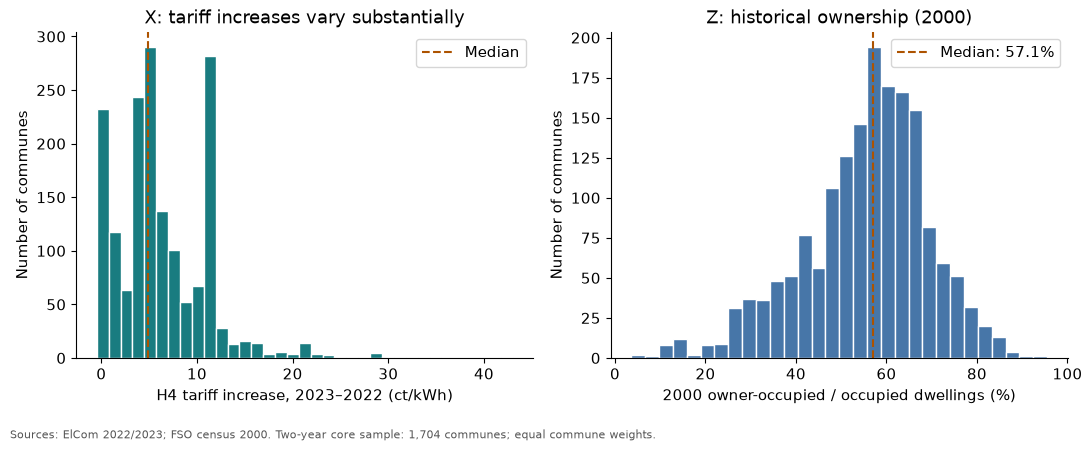

Mean ownership: 55.43%; median: 57.12%.
A commune mean is not the national dwelling-weighted ownership share.


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(commune_sample.X, bins=35, color="#197C80", edgecolor="white")
axes[0].axvline(commune_sample.X.median(), color="#AD5300", linestyle="--", label="Median")
axes[0].set(title="X: tariff increases vary substantially", xlabel="H4 tariff increase, 2023–2022 (ct/kWh)", ylabel="Number of communes")
axes[0].legend()
axes[1].hist(100 * commune_sample.Z, bins=30, color="#4776A8", edgecolor="white")
axes[1].axvline(100 * ownership_median, color="#AD5300", linestyle="--", label=f"Median: {100*ownership_median:.1f}%")
axes[1].set(title="Z: historical ownership (2000)", xlabel="2000 owner-occupied / occupied dwellings (%)", ylabel="Number of communes")
axes[1].legend()
save_figure(fig, "01_X_Z_distributions.png", f"Sources: ElCom 2022/2023; FSO census 2000. Two-year core sample: {len(commune_sample):,} communes; equal commune weights.")
print(f"Mean ownership: {commune_sample.Z.mean():.2%}; median: {ownership_median:.2%}.")
print("A commune mean is not the national dwelling-weighted ownership share.")

In [64]:
extremes = pd.concat([commune_sample.nsmallest(5, "X"), commune_sample.nlargest(5, "X")])
display(extremes[["bfs", "commune", "canton", "X", "n_operators_2022", "n_operators_2023"]])
canton_variation = commune_sample.groupby("canton").agg(N=("X", "size"), mean_X=("X", "mean"),
                                                       SD_X=("X", "std"), min_X=("X", "min"), max_X=("X", "max"))
canton_variation.to_csv(TABLE_DIR / "within_canton_variation.csv")
display(canton_variation)

,bfs,commune,canton,X,n_operators_2022,n_operators_2023
1476,578,Gündlischwand,Bern / Berne,-0.4660,1.0000,1.0000
289,6032,Bourg-Saint-Pierre,Valais / Wallis,0.0000,1.0000,1.0000
489,4314,Mellikon,Aargau,0.0000,1.0000,1.0000
1908,3551,Brusio,Graubünden / Grigioni / Grischun,0.0000,1.0000,1.0000
1923,3695,Sufers,Graubünden / Grigioni / Grischun,0.0000,1.0000,1.0000
503,4073,Oberlunkhofen,Aargau,43.0000,1.0000,1.0000
1352,301,Aarberg,Bern / Berne,35.0640,1.0000,1.0000
1689,4646,Ermatingen,Thurgau,33.4460,1.0000,1.0000
1684,4831,Müllheim,Thurgau,32.7500,1.0000,1.0000
1738,4723,Braunau,Thurgau,29.8000,1.0000,1.0000


,N,mean_X,SD_X,min_X,max_X
canton,,,,,
Aargau,184,7.0947,5.3132,0.0000,43.0000
Appenzell Ausserrhoden,6,10.4978,6.5287,6.4400,21.4000
Appenzell Innerrhoden,5,7.9940,2.3406,6.7800,12.1700
Basel-Landschaft,79,5.1026,2.8363,0.3000,9.8530
Basel-Stadt,3,3.3160,0.0000,3.3160,3.3160
...,...,...,...,...,...
Uri,16,8.9938,3.9138,0.3000,15.6300
Valais / Wallis,83,7.1285,3.6851,0.0000,18.2450
Vaud,260,10.4218,1.9998,3.5750,13.3900


In [65]:
map_data = boundaries.merge(clean_x[["bfs", "X"]], on="bfs", how="left", validate="1:1")
map_data = map_data.merge(commune_data[["bfs", "in_analysis"]], on="bfs", how="left", validate="1:1").to_crs(2056)
print("Map municipalities:", len(map_data), "; X coverage:", map_data.X.notna().mean())

Map municipalities: 2110 ; X coverage: 0.9938388625592417


Drawing the tariff map...


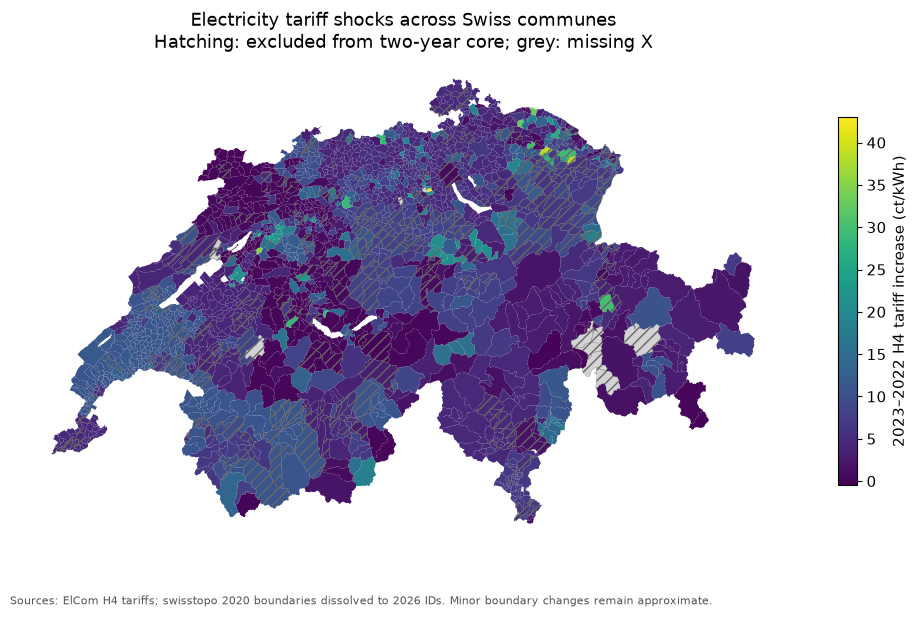

In [66]:
print("Drawing the tariff map...", flush=True)
fig, ax = plt.subplots(figsize=(10, 6))
map_data.plot(column="X", cmap="viridis", linewidth=0, legend=True, ax=ax,
              legend_kwds={"label": "2023–2022 H4 tariff increase (ct/kWh)", "shrink": 0.7},
              missing_kwds={"color": "lightgrey"})
map_data.loc[~map_data.in_analysis].plot(ax=ax, facecolor="none", edgecolor="#666666", linewidth=0.15, hatch="///")
ax.set_title("Electricity tariff shocks across Swiss communes\nHatching: excluded from two-year core; grey: missing X")
ax.set_axis_off()
save_figure(fig, "02_tariff_shock_map.png", "Sources: ElCom H4 tariffs; swisstopo 2020 boundaries dissolved to 2026 IDs. Minor boundary changes remain approximate.")

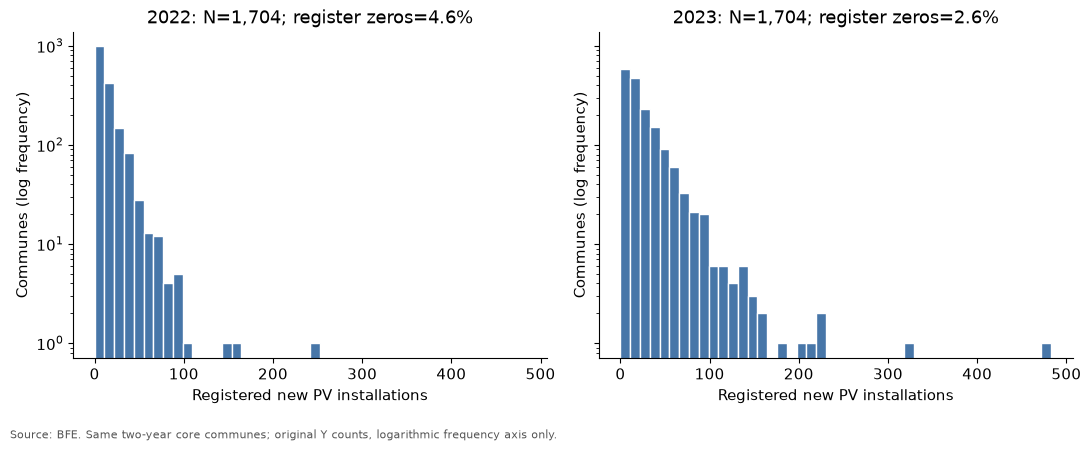

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
bins = np.linspace(0, panel.Y.max() + 1, 45)
for ax, year in zip(axes, [2022, 2023]):
    values = panel.loc[panel.year == year, "Y"]
    ax.hist(values, bins=bins, color="#4776A8", edgecolor="white")
    ax.set_yscale("log")
    ax.set(title=f"{year}: N={len(values):,}; register zeros={values.eq(0).mean():.1%}",
           xlabel="Registered new PV installations", ylabel="Communes (log frequency)")
save_figure(fig, "04_Y_two_year_distributions.png", "Source: BFE. Same two-year core communes; original Y counts, logarithmic frequency axis only.")

Y is shown as original counts with a logarithmic frequency axis. Z is historical ownership; its municipality average is not the national dwelling-weighted share.

<a id="growth"></a>
## 5. Tariff increases and PV growth
Compare count changes and changes per 1,000 baseline residents. Pearson measures linear association; Spearman measures rank association.

In [68]:
y_wide = panel.pivot(index="bfs", columns="year", values="Y")
growth = commune_sample.set_index("bfs").copy()
growth["Y_2022"] = y_wide[2022]
growth["Y_2023"] = y_wide[2023]
growth["growth_count"] = growth.Y_2023 - growth.Y_2022
growth["growth_per_1000"] = 1000 * growth.growth_count / growth.population_2021
growth.to_csv(PROCESSED_DIR / "core_commune_growth.csv")

In [69]:
correlation_rows = []
def correlation_row(label, data, x, y):
    pair = data[[x, y]].dropna()
    return {"comparison": label, "N": len(pair),
            "Pearson_r": pair[x].corr(pair[y]),
            "Spearman_r": pair[x].rank().corr(pair[y].rank())}

In [70]:
core_correlations = pd.DataFrame([
    correlation_row("Core: X vs count change 2023-2022", growth, "X", "growth_count"),
    correlation_row("Core: X vs change per 1000", growth, "X", "growth_per_1000")])
core_correlations.to_csv(TABLE_DIR / "core_correlations.csv", index=False)
display(core_correlations)
print("Annual totals in the same core sample:")
display(panel.groupby("year").Y.sum().to_frame("same_core_sample_total"))

,comparison,N,Pearson_r,Spearman_r
0,Core: X vs count change 2023-2022,1704,0.1565,0.1678
1,Core: X vs change per 1000,1704,0.1407,0.0982


Annual totals in the same core sample:


,same_core_sample_total
year,
2022,"22,482.0000"
2023,"41,636.0000"


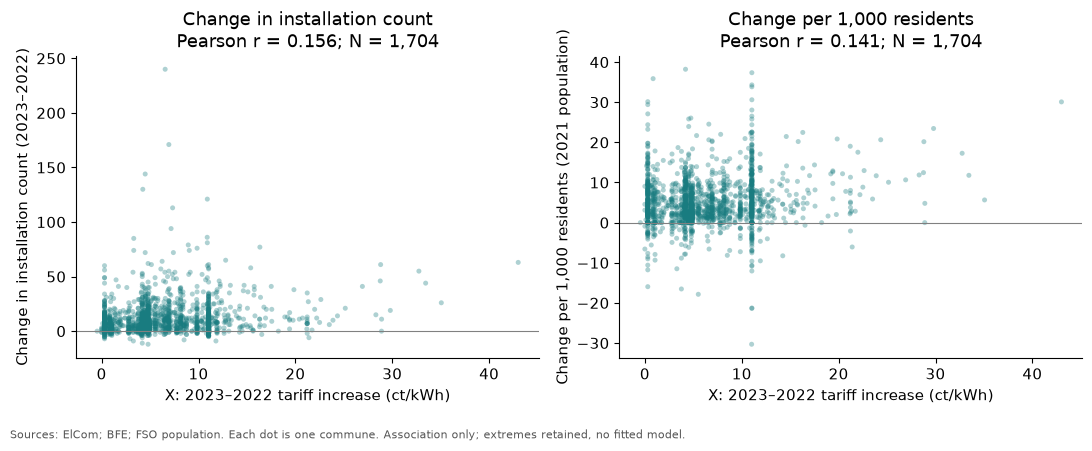

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, variable, label in [(axes[0], "growth_count", "Change in installation count (2023–2022)"),
                            (axes[1], "growth_per_1000", "Change per 1,000 residents (2021 population)")]:
    ax.scatter(growth.X, growth[variable], s=13, alpha=0.35, color="#197C80", edgecolors="none")
    ax.axhline(0, color="grey", linewidth=0.8)
    r = growth.X.corr(growth[variable])
    ax.set(title=f"{label.split(' (')[0]}\nPearson r = {r:.3f}; N = {len(growth):,}",
           xlabel="X: 2023–2022 tariff increase (ct/kWh)", ylabel=label)
save_figure(fig, "05_shock_and_solar_growth.png", "Sources: ElCom; BFE; FSO population. Each dot is one commune. Association only; extremes retained, no fitted model.")

<a id="ownership"></a>
## 6. Historical ownership groups
Compare both average growth and within-group tariff–growth correlations. Higher average growth does not mean greater sensitivity to electricity prices.

In [72]:
heterogeneity_rows = []
for label in ["Low ownership", "High ownership"]:
    subset = growth[growth.ownership_group == label]
    heterogeneity_rows.append(correlation_row(label, subset, "X", "growth_per_1000"))
heterogeneity = pd.DataFrame(heterogeneity_rows)
ownership_plot_means = growth.groupby(["ownership_group", "shock_group"], observed=True).agg(
    mean_X=("X", "mean"), mean_growth=("growth_per_1000", "mean"), N=("X", "size"))
display(heterogeneity)
display(ownership_plot_means)

,comparison,N,Pearson_r,Spearman_r
0,Low ownership,852,0.1488,0.0966
1,High ownership,852,0.1459,0.1079


mean_X  mean_growth    N
ownership_group shock_group                           
High ownership  Low shock     1.9637       5.3841  343
                Medium shock  5.5471       5.0005  231
                High shock   12.1397       7.1785  278
Low ownership   Low shock     1.9292       3.9547  270
                Medium shock  5.5928       3.6166  293
                High shock   11.6646       4.9561  289

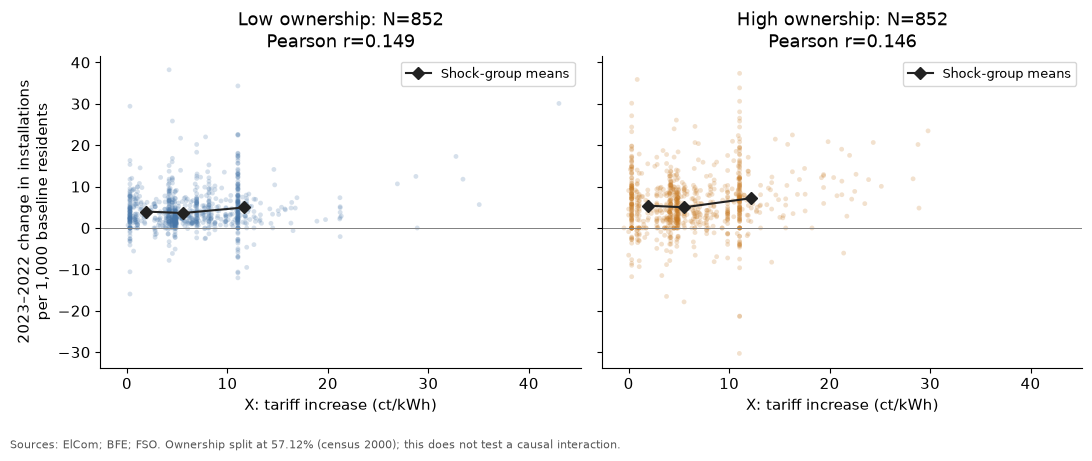

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, label, color in zip(axes, ["Low ownership", "High ownership"], ["#4776A8", "#C77922"]):
    subset = growth[growth.ownership_group == label]
    result = heterogeneity.set_index("comparison").loc[label]
    ax.scatter(subset.X, subset.growth_per_1000, s=12, alpha=0.22, color=color, edgecolors="none")
    means = ownership_plot_means.loc[label]
    ax.plot(means.mean_X, means.mean_growth, "D-", color="#222222", markersize=6, label="Shock-group means")
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.set(title=f"{label}: N={len(subset):,}\nPearson r={result['Pearson_r']:.3f}",
           xlabel="X: tariff increase (ct/kWh)")
    ax.legend(fontsize=9)
axes[0].set_ylabel("2023–2022 change in installations\nper 1,000 baseline residents")
save_figure(fig, "07_homeownership_comparison.png", f"Sources: ElCom; BFE; FSO. Ownership split at {100*ownership_median:.2f}% (census 2000); this does not test a causal interaction.")

In [74]:
ownership_levels = growth.groupby("ownership_group").agg(N=("X", "size"), mean_X=("X", "mean"),
    mean_Z=("Z", "mean"), mean_count_change=("growth_count", "mean"),
    mean_per_1000=("growth_per_1000", "mean"), median_per_1000=("growth_per_1000", "median"))
heterogeneity.to_csv(TABLE_DIR / "ownership_group_correlations.csv", index=False)
ownership_levels.to_csv(TABLE_DIR / "ownership_group_levels.csv")
ownership_plot_means.to_csv(TABLE_DIR / "ownership_shock_group_means.csv")
display(ownership_levels)

,N,mean_X,mean_Z,mean_count_change,mean_per_1000,median_per_1000
ownership_group,,,,,,
High ownership,852,6.2556,0.6612,7.9484,5.8656,5.3005
Low ownership,852,6.4914,0.4474,14.5329,4.1781,3.1496


### Related characteristics
Income, population and building structure may explain part of the observed association. Within-canton demeaning removes canton averages only.

In [75]:
correlation_rows = []
for variable in ["population_2021", "income_2021", "single_family_share_2021", "Z"]:
    correlation_rows.append(correlation_row(f"X vs {variable}", growth, "X", variable))
within = growth[growth.groupby("canton").X.transform("size") >= 2].copy()
within["X_within"] = within.X - within.groupby("canton").X.transform("mean")
within["growth_within"] = within.growth_per_1000 - within.groupby("canton").growth_per_1000.transform("mean")

In [76]:
correlation_rows.append(correlation_row("Within-canton descriptive correlation", within, "X_within", "growth_within"))
correlations = pd.DataFrame(correlation_rows)
correlations.to_csv(TABLE_DIR / "characteristic_correlations.csv", index=False)
display(correlations)

,comparison,N,Pearson_r,Spearman_r
0,X vs population_2021,1704,0.0128,0.0943
1,X vs income_2021,1704,0.1244,0.2197
2,X vs single_family_share_2021,1704,0.0432,0.0483
3,X vs Z,1704,-0.0570,-0.0816
4,Within-canton descriptive correlation,1703,0.1401,0.0978


<a id="supplementary"></a>
## 7. Supplementary time comparisons
Long-term trends use a fixed 2015–2025 balanced sample. Tariff-group indices set each group's 2021 total to 100. Earlier/follow-up comparisons check their own required years and never reduce the core sample.

In [77]:
trend_panel["usable_zero"] = trend_panel.Y.eq(0)
yearly = trend_panel.groupby("year").agg(N=("bfs", "nunique"), installations=("Y", "sum"),
                                       mean_Y=("Y", "mean"), zero_share=("usable_zero", "mean"))
assert yearly.N.eq(len(balanced_communes)).all()
yearly.to_csv(TABLE_DIR / "long_trend_yearly.csv")
display(yearly)

,N,installations,mean_Y,zero_share
year,,,,
2015,1458,"6,436.0000",4.4143,0.1578
2016,1458,"5,445.0000",3.7346,0.1948
2017,1458,"6,969.0000",4.7798,0.1502
2018,1458,"6,768.0000",4.6420,0.1728
2019,1458,"7,661.0000",5.2545,0.1392
2020,1458,"10,159.0000",6.9678,0.0912
2021,1458,"11,964.0000",8.2058,0.0802
2022,1458,"16,837.0000",11.5480,0.0480
2023,1458,"31,544.0000",21.6351,0.0267


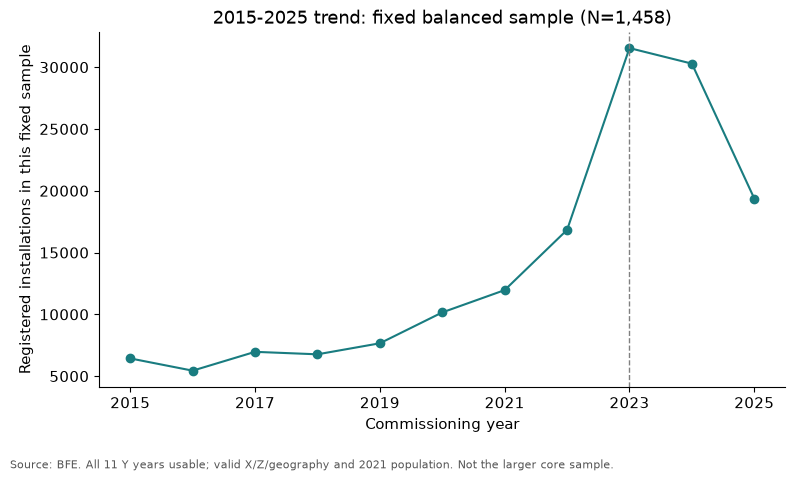

In [78]:
fig, ax = plt.subplots()
ax.plot(yearly.index, yearly.installations, "o-", color="#197C80")
ax.axvline(2023, color="grey", linestyle="--", linewidth=1)
ax.set(title=f"2015-2025 trend: fixed balanced sample (N={len(balanced_communes):,})",
       xlabel="Commissioning year", ylabel="Registered installations in this fixed sample")
ax.set_xticks(range(2015, 2026, 2))
save_figure(fig, "03_long_trend_balanced.png", "Source: BFE. All 11 Y years usable; valid X/Z/geography and 2021 population. Not the larger core sample.")

In [79]:
group_totals = trend_panel.groupby(["year", "shock_group"], observed=True).Y.sum().unstack()
assert group_totals.loc[2021].gt(0).all()
indexed_trends = group_totals.div(group_totals.loc[2021]).mul(100)
trend_group_counts = trend_panel.drop_duplicates("bfs").groupby("shock_group", observed=True).size()
indexed_trends.to_csv(TABLE_DIR / "long_trend_group_indices.csv")
display(indexed_trends.loc[2021:2025])
display(trend_group_counts.to_frame("fixed_communes"))

shock_group,Low shock,Medium shock,High shock
year,,,
2021,100.0000,100.0000,100.0000
2022,142.9919,139.6341,139.7150
2023,238.1189,264.3857,289.0024
2024,227.5347,256.3008,275.6655
2025,141.1580,180.0361,161.6295


,fixed_communes
shock_group,
Low shock,529
Medium shock,451
High shock,478


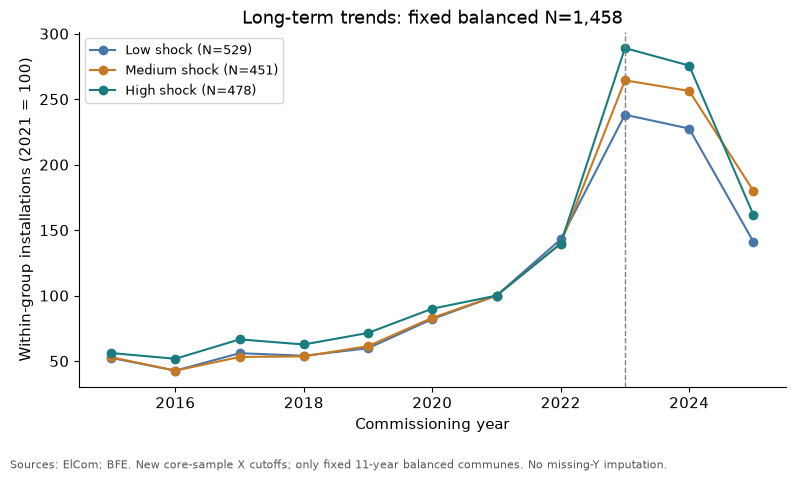

In [80]:
fig, ax = plt.subplots()
for label, color in zip(["Low shock", "Medium shock", "High shock"], ["#4776A8", "#C77922", "#197C80"]):
    ax.plot(indexed_trends.index, indexed_trends[label], "o-", color=color,
            label=f"{label} (N={int(trend_group_counts[label])})")
ax.axvline(2023, color="grey", linestyle="--", linewidth=1)
ax.set(title=f"Long-term trends: fixed balanced N={len(balanced_communes):,}",
       xlabel="Commissioning year", ylabel="Within-group installations (2021 = 100)")
ax.legend(fontsize=9)
save_figure(fig, "06_long_trend_shock_groups.png", "Sources: ElCom; BFE. New core-sample X cutoffs; only fixed 11-year balanced communes. No missing-Y imputation.")

In [81]:
extra_comparisons = []
for label, end_year, start_year in [("Earlier: 2022-2021", 2022, 2021), ("Follow-up: 2024-2022", 2024, 2022)]:
    available = y_all.loc[growth.index, [start_year, end_year]].notna().all(axis=1)
    subset = growth.loc[available].copy()
    count_change = y_all.loc[subset.index, end_year] - y_all.loc[subset.index, start_year]
    subset["extra_growth"] = 1000 * count_change / subset.population_2021
    result = correlation_row(label, subset, "X", "extra_growth")
    result["excluded_from_core_for_this_comparison"] = len(growth) - len(subset)
    extra_comparisons.append(result)
    subset[["X", "extra_growth"]].to_csv(PROCESSED_DIR / f"comparison_{end_year}_{start_year}.csv")

In [82]:
extra_results = pd.DataFrame(extra_comparisons)
extra_results.to_csv(TABLE_DIR / "other_year_comparisons.csv", index=False)
display(extra_results)

,comparison,N,Pearson_r,Spearman_r,excluded_from_core_for_this_comparison
0,Earlier: 2022-2021,1670,0.0278,0.0267,34
1,Follow-up: 2024-2022,1587,0.1126,0.1173,117


## 8. Sensitivity checks
Check X extremes, operator composition, positive baseline Y, attached/integrated PV, coordinate-only records and balanced-sample selection. Alternative definitions remain supplementary.

In [83]:
sensitivity_rows = [correlation_row("Main two-year core sample", growth, "X", "growth_per_1000")]
lo, hi = growth.X.quantile([0.01, 0.99])
trimmed = growth[growth.X.between(lo, hi)]
stable = growth[growth.stable_operator_set]
positive_baseline = growth[growth.Y_2022 > 0]
sensitivity_rows.append(correlation_row("X between 1st and 99th percentiles", trimmed, "X", "growth_per_1000"))
sensitivity_rows.append(correlation_row("Same operators in both years", stable, "X", "growth_per_1000"))
sensitivity_rows.append(correlation_row("Same-operator-pair X proxy", growth, "X_same_operators", "growth_per_1000"))
sensitivity_rows.append(correlation_row("Positive Y in 2022 only (selected)", positive_baseline, "X", "growth_per_1000"))

In [84]:
for variable, label in [("Y_rooftop_registered", "Attached/integrated PV proxy only"),
                        ("Y_coordinate_only", "Coordinate-assigned records only")]:
    wide = panel.pivot(index="bfs", columns="year", values=variable)
    check = growth.copy()
    check["alternate_growth"] = 1000 * (wide[2023] - wide[2022]) / check.population_2021
    sensitivity_rows.append(correlation_row(label, check, "X", "alternate_growth"))
display(pd.DataFrame(sensitivity_rows).tail(2))

,comparison,N,Pearson_r,Spearman_r
5,Attached/integrated PV proxy only,1704,0.1369,0.0953
6,Coordinate-assigned records only,1704,0.1391,0.0960


In [85]:
balanced_growth = growth.loc[growth.index.isin(balanced_communes.bfs)].copy()
sensitivity_rows.append(correlation_row("Rebuilt fixed 11-year balanced subset", balanced_growth, "X", "growth_per_1000"))
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(TABLE_DIR / "sensitivity_checks.csv", index=False)
display(sensitivity)

,comparison,N,Pearson_r,Spearman_r
0,Main two-year core sample,1704,0.1407,0.0982
1,X between 1st and 99th percentiles,1676,0.0838,0.0765
2,Same operators in both years,1629,0.1427,0.0969
3,Same-operator-pair X proxy,1702,0.1407,0.1005
4,Positive Y in 2022 only (selected),1625,0.1590,0.1074
5,Attached/integrated PV proxy only,1704,0.1369,0.0953
6,Coordinate-assigned records only,1704,0.1391,0.0960
7,Rebuilt fixed 11-year balanced subset,1458,0.1482,0.1018


## 9. VESE: competing feed-in incentives
Match exact operator/year IDs and require complete operator coverage. Verify energy/eco payment components; compare all matches and the fixed/nonflagged subset. Preserve the team's supplied plausibility flags, whose construction is undocumented. VESE does not replace X.

In [86]:
vese_operator = pd.read_csv(VESE_DIR / "vese_feedin_operator_year.csv")
vese_api = pd.read_csv(VESE_DIR / "vese_operator_year_all_api_fields.csv")
vese_shock = pd.read_csv(VESE_DIR / "vese_feedin_commune_shock.csv")
assert not vese_operator.duplicated(["operator", "year"]).any()
assert not vese_api.duplicated(["operator", "year"]).any()
assert vese_shock.bfs.is_unique
identity_check = vese_api[["operator", "nrElcom"]].dropna()
assert (identity_check.operator == identity_check.nrElcom).all()

In [87]:
recomputed_fit = vese_operator.energy1 + vese_operator.eco1.where(~vese_operator.ecoIncl, 0)
valid_fit_check = recomputed_fit.notna() & vese_operator.fit_total.notna()
assert np.allclose(recomputed_fit[valid_fit_check], vese_operator.loc[valid_fit_check, "fit_total"])
# Check the processed energy fields against their original API values.
api_check = vese_operator.merge(vese_api[["operator", "year", "energy1", "eco1"]],
                               on=["operator", "year"], validate="1:1", suffixes=("", "_api"))
for field in ["energy1", "eco1"]:
    good = api_check[[field, field + "_api"]].notna().all(axis=1)
    assert np.allclose(api_check.loc[good, field], api_check.loc[good, field + "_api"])
print("Feed-in formula and API values verified:", int(valid_fit_check.sum()), "operator-years.")

Feed-in formula and API values verified: 4413 operator-years.


In [88]:
vese_coverage = vese_operator.groupby("year").agg(operator_rows=("operator", "size"),
    available_fit=("fit_total", "count"), min_fit=("fit_total", "min"), max_fit=("fit_total", "max"),
    market_indexed=("market_indexed", "sum"))
display(vese_coverage)
print("Validated fit_total formula on", int(valid_fit_check.sum()), "operator-years.")
print("Duplicate keys in VESE source tables: 0.")

,operator_rows,available_fit,min_fit,max_fit,market_indexed
year,,,,,
2017,397,397,3.5000,25.0000,9
2018,304,304,3.5000,23.0000,8
2019,460,458,3.6700,25.0000,6
2020,462,462,4.2000,23.0000,3
2021,468,467,3.0000,23.0000,3
2022,471,470,4.8500,33.0000,8
2023,466,465,5.0000,39.1000,11
2024,493,490,4.4100,36.3000,11
2025,482,480,5.5000,31.0000,37


Validated fit_total formula on 4413 operator-years.
Duplicate keys in VESE source tables: 0.


In [89]:
vese_selected = vese_operator.loc[vese_operator.year.isin([2022, 2023]),
    ["operator", "year", "fit_total", "fit_selfconsumer", "market_indexed"]].rename(columns={"year": "period"})
vese_links = operator_tariffs.merge(vese_selected, on=["operator", "period"], how="left", validate="m:1")
print("Matched rows:", vese_links.fit_total.notna().sum(), "/", len(vese_links))

Matched rows: 4333 / 4601


In [90]:
vese_annual = vese_links.groupby(["bfs", "period"]).agg(
    n_elcom=("operator", "size"), n_vese=("fit_total", "count"),
    fit=("fit_total", "mean"), fit_selfconsumer=("fit_selfconsumer", "mean"),
    n_selfconsumer=("fit_selfconsumer", "count"), any_market=("market_indexed", "max"))
vese_annual.loc[vese_annual.n_vese != vese_annual.n_elcom, "fit"] = np.nan
vese_annual.loc[vese_annual.n_selfconsumer != vese_annual.n_elcom, "fit_selfconsumer"] = np.nan

In [91]:
vese_wide = vese_annual.unstack("period")
vese_wide.columns = [f"{column}_{year}" for column, year in vese_wide.columns]
clean_vese = commune_data[["bfs", "commune", "canton", "X", "in_analysis"]].merge(
    vese_wide, on="bfs", how="left", validate="1:1")
clean_vese["fit_change"] = clean_vese.fit_2023 - clean_vese.fit_2022
clean_vese["selfconsumer_change"] = clean_vese.fit_selfconsumer_2023 - clean_vese.fit_selfconsumer_2022

In [92]:
clean_vese["market_indexed_either_year"] = clean_vese.any_market_2022.fillna(False).astype(bool) | clean_vese.any_market_2023.fillna(False).astype(bool)
flagged_ids = set(vese_shock.loc[vese_shock.flag_implausible_2022, "bfs"].map(to_2026))
clean_vese["team_plausibility_flag"] = clean_vese.bfs.isin(flagged_ids)
clean_vese["in_vese_diagnostic"] = (clean_vese.in_analysis & clean_vese.fit_change.notna()
                                     & ~clean_vese.market_indexed_either_year & ~clean_vese.team_plausibility_flag)

In [93]:
clean_vese.to_csv(PROCESSED_DIR / "clean_VESE_robustness.csv", index=False)
vese_complete = clean_vese[clean_vese.in_analysis & clean_vese.fit_change.notna()].copy()
vese_main = clean_vese[clean_vese.in_vese_diagnostic].copy()
print("Complete matches:", len(vese_complete), "| Fixed/nonflagged:", len(vese_main))

Complete matches: 1591 | Fixed/nonflagged: 1245


In [94]:
vese_results = [correlation_row("X vs feed-in change: all complete matches", vese_complete, "X", "fit_change"),
                correlation_row("X vs feed-in change: fixed/nonflagged", vese_main, "X", "fit_change"),
                correlation_row("X vs 2023 feed-in level: fixed/nonflagged", vese_main, "X", "fit_2023"),
                correlation_row("X vs selfconsumer change: fixed/nonflagged", vese_main, "X", "selfconsumer_change")]
display(pd.DataFrame(vese_results))

,comparison,N,Pearson_r,Spearman_r
0,X vs feed-in change: all complete matches,1591,0.6313,0.7958
1,X vs feed-in change: fixed/nonflagged,1245,0.8118,0.7914
2,X vs 2023 feed-in level: fixed/nonflagged,1245,0.8186,0.7598
3,X vs selfconsumer change: fixed/nonflagged,1245,0.8108,0.7903


In [95]:
# One row per operator: average its retail tariff across the two-year-core communes it serves.
op_retail = operator_tariffs[operator_tariffs.bfs.isin(commune_sample.bfs)].groupby(["operator", "period"]).total.mean().unstack()
op_fit = vese_selected.pivot(index="operator", columns="period", values="fit_total")
op_check = pd.DataFrame({"retail_change": op_retail[2023] - op_retail[2022],
                         "fit_change": op_fit[2023] - op_fit[2022]})
market_operators = set(vese_selected.loc[vese_selected.market_indexed, "operator"])
flagged_operators = set(vese_shock.loc[vese_shock.flag_implausible_2022, "main_operator"])
op_check = op_check.loc[~op_check.index.isin(market_operators | flagged_operators)].dropna()
vese_results.append(correlation_row("Operator-level fixed/nonflagged diagnostic", op_check, "retail_change", "fit_change"))
vese_results = pd.DataFrame(vese_results)
vese_results.to_csv(TABLE_DIR / "vese_correlations.csv", index=False)
display(vese_results)
print("Exact ElCom operator-year links with VESE:", vese_links.fit_total.notna().sum(), "/", len(vese_links))

,comparison,N,Pearson_r,Spearman_r
0,X vs feed-in change: all complete matches,1591,0.6313,0.7958
1,X vs feed-in change: fixed/nonflagged,1245,0.8118,0.7914
2,X vs 2023 feed-in level: fixed/nonflagged,1245,0.8186,0.7598
3,X vs selfconsumer change: fixed/nonflagged,1245,0.8108,0.7903
4,Operator-level fixed/nonflagged diagnostic,339,0.8040,0.7985


Exact ElCom operator-year links with VESE: 4333 / 4601


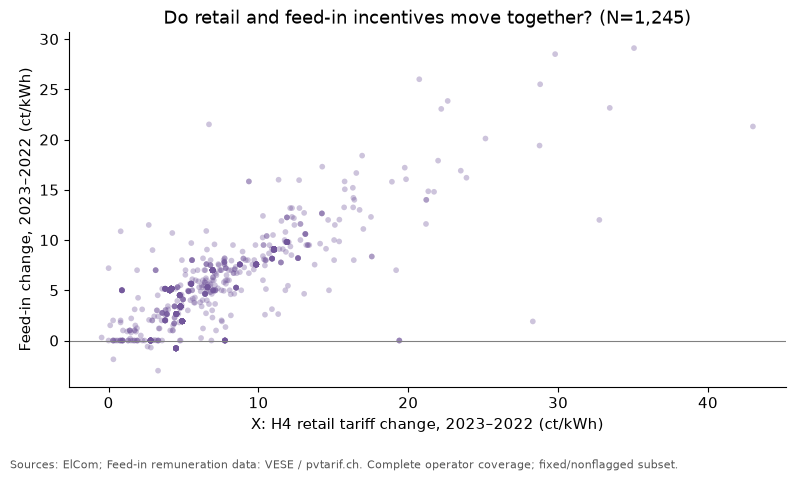

In [96]:
fig, ax = plt.subplots()
ax.scatter(vese_main.X, vese_main.fit_change, s=17, alpha=0.35, color="#72569B", edgecolors="none")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set(title=f"Do retail and feed-in incentives move together? (N={len(vese_main):,})",
       xlabel="X: H4 retail tariff change, 2023–2022 (ct/kWh)",
       ylabel="Feed-in change, 2023–2022 (ct/kWh)")
save_figure(fig, "08_VESE_retail_vs_feedin.png", "Sources: ElCom; Feed-in remuneration data: VESE / pvtarif.ch. Complete operator coverage; fixed/nonflagged subset.")

Retail and feed-in co-movement is a competing explanation, not proof of a causal effect. Source: [VESE](https://www.vese.ch) / [pvtarif.ch](https://www.pvtarif.ch). Public-sharing conditions are documented in `DATA_SOURCES.md`.

## 10. Core versus balanced sample
Both samples are rebuilt from source inputs. Compare characteristics and correlations, not installation totals across differently sized samples.

In [97]:
profile_rows = []
for label, subset in [("Two-year core", commune_sample), ("Rebuilt balanced", balanced_communes), ("Newly included", newly_included)]:
    for variable in ["X", "Z", "population_2021", "income_2021", "single_family_share_2021"]:
        values = subset[variable]
        profile_rows.append({"sample": label, "variable": variable, "communes": len(subset), "N": values.count(),
            "mean": values.mean(), "SD": values.std(), "median": values.median(), "min": values.min(), "max": values.max()})
profiles = pd.DataFrame(profile_rows)
profiles.to_csv(TABLE_DIR / "sample_characteristics_comparison.csv", index=False)
display(profiles[["sample", "variable", "N", "mean", "median"]])

,sample,variable,N,mean,median
0,Two-year core,X,1704,6.3735,4.9170
1,Two-year core,Z,1704,0.5543,0.5712
2,Two-year core,population_2021,1704,"3,206.0012","1,454.0000"
3,Two-year core,income_2021,1704,"60,932.1503","58,385.1006"
4,Two-year core,single_family_share_2021,1704,0.5975,0.6188
5,Rebuilt balanced,X,1458,6.3409,4.9170
6,Rebuilt balanced,Z,1458,0.5598,0.5752
7,Rebuilt balanced,population_2021,1458,"2,702.2840","1,332.0000"
8,Rebuilt balanced,income_2021,1458,"61,098.8056","58,760.4787"
9,Rebuilt balanced,single_family_share_2021,1458,0.6007,0.6242


In [98]:
sample_comparison_rows = []
for label, subset in [("Two-year core", growth), ("Rebuilt balanced", balanced_growth),
                      ("Newly included", growth.loc[newly_included.bfs])]:
    for variable in ["growth_count", "growth_per_1000"]:
        row = correlation_row(label, subset, "X", variable)
        row["outcome"] = variable
        sample_comparison_rows.append(row)
sample_correlations = pd.DataFrame(sample_comparison_rows)
sample_correlations.to_csv(TABLE_DIR / "sample_correlations_comparison.csv", index=False)
display(sample_correlations)

,comparison,N,Pearson_r,Spearman_r,outcome
0,Two-year core,1704,0.1565,0.1678,growth_count
1,Two-year core,1704,0.1407,0.0982,growth_per_1000
2,Rebuilt balanced,1458,0.1885,0.1794,growth_count
3,Rebuilt balanced,1458,0.1482,0.1018,growth_per_1000
4,Newly included,246,0.0631,0.0951,growth_count
5,Newly included,246,0.0801,0.0693,growth_per_1000


## 11. Verification
Check formulas, missingness, sample membership rules and figure inputs.

In [99]:
assert clean_y.loc[clean_y.unresolved_location_risk | ~clean_y.has_polygon, "Y"].isna().all()
reliable = ~clean_y.unresolved_location_risk & clean_y.has_polygon
assert np.array_equal(clean_y.loc[reliable, "Y"], clean_y.loc[reliable, "Y_registered"])
assert panel.Y.ge(0).all() and panel.Y.mod(1).eq(0).all()
assert not panel.unresolved_location_risk.any()
assert growth.Y_2022.notna().all() and growth.Y_2023.notna().all()
assert np.allclose(growth.growth_count, growth.Y_2023 - growth.Y_2022)
assert np.allclose(growth.growth_per_1000, 1000 * growth.growth_count / growth.population_2021)
assert np.allclose(clean_x.X.dropna(), (clean_x.tariff_2023 - clean_x.tariff_2022).dropna())
assert np.allclose(clean_z.Z.dropna(), (clean_z.owner_dwellings / clean_z.occupied_dwellings).dropna())
print("Missingness, register zeros and growth formulas verified.")

Missingness, register zeros and growth formulas verified.


In [100]:
assert summary.N.eq(len(commune_sample)).all()
assert group_counts.N.sum() == len(commune_sample)
assert group_counts.long_trend_N.sum() == len(balanced_communes)
assert growth.ownership_group.value_counts().sum() == len(growth)
assert indexed_trends.loc[2021].eq(100).all()
assert np.allclose(group_totals.sum(axis=1), yearly.installations)
assert np.isclose(ownership_median, growth.Z.median())
assert np.allclose(shock_cuts, growth.X.quantile([1/3, 2/3]))
assert np.allclose(ownership_plot_means.mean_growth,
    growth.groupby(["ownership_group", "shock_group"], observed=True).growth_per_1000.mean())
print("Summary, group cutoffs/counts and figure inputs verified.")

Summary, group cutoffs/counts and figure inputs verified.


In [101]:
r_main = growth.X.corr(growth.growth_per_1000)
r_count = growth.X.corr(growth.growth_count)
r_balanced = balanced_growth.X.corr(balanced_growth.growth_per_1000)
r_balanced_count = balanced_growth.X.corr(balanced_growth.growth_count)
r_vese = vese_main.X.corr(vese_main.fit_change)
metrics = {"core_N": len(growth), "balanced_N": len(balanced_growth), "new_N": len(newly_included),
    "core_r_count": r_count, "core_r_per_1000": r_main, "balanced_r_count": r_balanced_count,
    "balanced_r_per_1000": r_balanced, "median_Z": ownership_median, "X_cut_low": shock_cuts[0],
    "X_cut_high": shock_cuts[1], "vese_complete_N": len(vese_complete), "vese_N": len(vese_main), "vese_r": r_vese}
(REPORT_DIR / "key_results.json").write_text(json.dumps(metrics, indent=2))
display(pd.Series(metrics).to_frame("Results"))

,Results
core_N,"1,704.0000"
balanced_N,"1,458.0000"
new_N,246.0000
core_r_count,0.1565
core_r_per_1000,0.1407
balanced_r_count,0.1885
balanced_r_per_1000,0.1482
median_Z,0.5712
X_cut_low,4.1950
X_cut_high,7.8230


<a id="findings"></a>
## 12. Key findings

In [102]:
findings = pd.DataFrame({
    "Result": ["Core municipalities", "Balanced municipalities", "Pearson: X vs count growth",
               "Pearson: X vs growth per 1,000", "Historical ownership median"],
    "Value": [f"{len(growth):,}", f"{len(balanced_growth):,}", f"{r_count:.3f}",
              f"{r_main:.3f}", f"{ownership_median:.2%}"]})
display(findings)
report_sections = [findings.to_string(index=False)]

,Result,Value
0,Core municipalities,"1,704"
1,Balanced municipalities,"1,458"
2,Pearson: X vs count growth,0.156
3,"Pearson: X vs growth per 1,000",0.141
4,Historical ownership median,57.12%


In [103]:
interpretation = f"""The tariff–PV growth relationship is weakly positive (r={r_main:.3f} per 1,000 residents).
Low/high historical-ownership groups have mean normalized growth of **{ownership_levels.loc['Low ownership','mean_per_1000']:.2f} / {ownership_levels.loc['High ownership','mean_per_1000']:.2f}**, with within-group correlations of **{heterogeneity.iloc[0].Pearson_r:.3f} / {heterogeneity.iloc[1].Pearson_r:.3f}**.
Higher growth in the high-ownership group does not establish greater price sensitivity or significant heterogeneity.
VESE retail/feed-in changes move together (r={r_vese:.3f}; N={len(vese_main):,}), suggesting competing incentives."""
display(Markdown(interpretation))
report_sections.append(interpretation)

The tariff–PV growth relationship is weakly positive (r=0.141 per 1,000 residents).
Low/high historical-ownership groups have mean normalized growth of **4.18 / 5.87**, with within-group correlations of **0.149 / 0.146**.
Higher growth in the high-ownership group does not establish greater price sensitivity or significant heterogeneity.
VESE retail/feed-in changes move together (r=0.812; N=1,245), suggesting competing incentives.

### Three interpretation limits
- Associations are descriptive: income, geography, other incentives, timing and reverse relationships may matter.
- Ownership is measured in 2000; it may not represent ownership in 2023.
- Y covers registered operating PV plants, not a complete residential-rooftop census. Reporting, approximate boundaries and sample exclusions affect coverage.

In [104]:
report_sections.append("""## Limitations
Historical ownership is measured in 2000. All-PV register coverage, survival/reporting, approximate 2020 polygons, equal operator weighting, unresolved-location exclusions and sample selection remain limitations.
Income, housing, geography, incentives, financing, installer supply, reverse relationships and anticipation can confound the associations. Descriptive EDA does not identify causal price effects or significant heterogeneity.
All comparisons are rebuilt from source inputs. The supplied VESE flags remain externally prepared and incompletely documented.
""")
report = "\n".join(report_sections)
(REPORT_DIR / "reference_report.md").write_text(report, encoding="utf-8")

1242

**Sources:** ElCom; SFOE/BFE; FSO; ESTV; Federal Office of Topography swisstopo; VESE / pvtarif.ch. Input versions and acquisition details: [DATA_SOURCES.md](DATA_SOURCES.md).